In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
class AE(nn.Module):
    def __init__(self, input_size, latent_size):
        super(AE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size

        # encoder network
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )
        # decoder network
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)
        
#load trained model
def load_model(input_size, latent_size):
    model = AE(input_size=input_size, latent_size=latent_size)
    model.load_state_dict(
        torch.load("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Autoencoder/autoencoder_lr_scheduler.pth")
    )
    model.eval()
    return model
model = load_model(103,10)

In [3]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data"

euler_nr = pd.read_csv(os.path.join(path, "euler_nr_data.csv"))
datatable = pd.read_csv(os.path.join(path, "Final_data.csv"))

euler_nr = euler_nr[['SubjectID', 'avg_euler_centered_neg_sqrt']].copy()
df_ae = datatable.merge(euler_nr, how="right")
df_ae = df_ae.iloc[:, 1:]
df_ae = df_ae.dropna(axis=1)

#these cols had only zeros (left-vessel had 0s in some cases but not all --> may fit a separate model for this)
#df_ae = df_ae.drop(columns=['5th-Ventricle','Left-WM-hypointensities','Left-non-WM-hypointensities','Left-vessel','Left-WM-hypointensities','Left-non-WM-hypointensities','Right-WM-hypointensities','Right-non-WM-hypointensities', 'non-WM-hypointensities'])
df_ae["avg_euler_centered_neg_sqrt"] = df_ae["avg_euler_centered_neg_sqrt"].astype(float)
df_ae = df_ae[df_ae["avg_euler_centered_neg_sqrt"] < 10.0]

df_ae = df_ae.drop(columns=
                   ['avg_euler_centered_neg_sqrt',
                    '5th-Ventricle',
                    'Left-WM-hypointensities',
                    'Left-non-WM-hypointensities',
                    'Left-vessel','Left-WM-hypointensities',
                    'Left-non-WM-hypointensities','Right-WM-hypointensities',
                    'Right-non-WM-hypointensities', 'non-WM-hypointensities',
                   'Year_initial_scan','Birthyear','SubjectID'])


#df_unseen.to_csv('unseen_data.csv')
first_cols = ["Age", "Sex", "Site"]
other_cols = df_ae.columns.difference(first_cols, sort=False)
df_ae = df_ae[first_cols + list(other_cols)]
df_ae = df_ae.iloc[3000:,:]
df = df_ae.iloc[:,3:]
df

,lh_G_front_inf-Triangul_thickness,lh_G_front_middle_thickness,lh_G_front_sup_thickness,lh_G_oc-temp_lat-fusifor_thickness,lh_G_oc-temp_med-Lingual_thickness,lh_G_oc-temp_med-Parahip_thickness,lh_G_occipital_middle_thickness,lh_G_orbital_thickness,lh_G_pariet_inf-Angular_thickness,lh_G_pariet_inf-Supramar_thickness,...,Right-Cerebellum-White-Matter,Right-Hippocampus,Right-Inf-Lat-Vent,Right-Lateral-Ventricle,Right-Pallidum,Right-Putamen,Right-VentralDC,Right-choroid-plexus,Right-vessel,WM-hypointensities
3000,2.457,2.544,2.796,2.772,2.026,3.249,2.781,2.718,2.663,2.851,...,16339.6,4638.0,309.3,7836.9,2045.6,4098.1,4729.6,646.2,12.4,1194.8
3001,2.758,2.787,3.095,3.274,2.025,3.340,2.667,2.866,2.886,2.902,...,15364.8,3838.5,452.3,24553.3,2064.8,5004.8,4235.9,871.0,34.9,3504.7
3002,2.805,2.634,2.831,2.933,1.982,2.811,2.837,2.750,2.933,2.717,...,14382.1,4231.6,283.2,12708.7,2178.6,5228.4,4065.3,912.3,35.4,3403.7
3003,2.869,2.822,3.124,3.310,2.172,3.485,2.719,2.884,2.763,2.903,...,17976.6,4190.1,472.6,7700.5,2155.3,4010.4,4389.7,373.0,9.2,963.2
3004,3.150,3.104,3.348,3.342,2.093,3.102,2.754,2.890,2.959,3.027,...,14179.4,4236.0,237.5,14395.9,1839.6,5499.1,4192.2,626.1,29.9,1157.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33547,2.743,2.868,3.188,2.943,2.110,3.555,2.797,3.222,2.769,2.906,...,13655.3,3615.6,184.7,5069.1,1948.0,4886.7,3755.6,439.9,0.0,885.3
33548,2.620,2.807,2.965,3.055,2.270,3.299,2.677,2.676,2.654,2.676,...,17395.7,5061.8,200.3,7450.8,2218.5,5947.9,4495.4,542.9,28.6,1157.0
33549,2.838,2.639,2.796,2.808,2.121,3.124,2.659,2.616,2.545,2.881,...,15070.7,3852.9,767.5,18407.2,2230.5,5115.0,4217.3,1193.6,31.2,2548.0
33550,3.115,3.135,3.192,3.233,2.275,3.257,2.900,2.910,3.113,3.277,...,15405.8,4711.2,345.6,5708.0,2154.0,6162.5,4185.9,415.3,112.8,971.6


In [4]:
#original training data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=1107)
scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

train_tensor = torch.tensor(train_scaled, dtype=torch.float32)
test_tensor = torch.tensor(test_scaled, dtype=torch.float32)

training_data = TensorDataset(train_tensor)
test_data = TensorDataset(test_tensor)

In [5]:
#training data with age/sex/site-location
train_df_asl, test_df_asl = train_test_split(df_ae, test_size=0.2, random_state=1107)

In [16]:
# encode data
with torch.no_grad():
    latent_representations = model.encode(test_tensor).numpy()

df_latents = pd.DataFrame(latent_representations)
test_df_asl = pd.DataFrame(test_df_asl)

# get last columns
test_df_asl = test_df_asl.iloc[:, :3].reset_index(drop=True)

"""
In the original PCA I did, I had to scale the data. Do we also need to do this for the latent representations?
""" 
# scaler = StandardScaler()
# latent_scaled = scaler.fit_transform(latent_representations)

pca = PCA(n_components=10)
latent_pca = pca.fit_transform(latent_representations) #latent_scaled if scaling is needed

#make dataframes and concat
latent_pca_df = pd.DataFrame(latent_pca).reset_index(drop=True)
latent_pca_df_asl = pd.concat([latent_pca_df, test_df_asl], axis=1)

latent_pca_df_asl = latent_pca_df_asl.rename(columns={i: f"PC{1+i}" for i in range(latent_pca.shape[1])})
print(latent_pca_df_asl)

           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0    -0.916289 -0.011156 -1.804126 -0.726909  0.085568  0.004311 -0.341781   
1     0.248145  1.191418  0.033541  0.472312 -0.554198  0.461357 -0.860981   
2    -1.697515  1.804938  2.011574 -0.821738  0.617370  0.632159 -0.420108   
3     0.237703  2.372940 -0.150467 -0.651240 -0.739450 -0.877172  0.589807   
4    -0.861067  0.036061 -0.894917  0.927540  0.375201 -0.178462 -0.695211   
...        ...       ...       ...       ...       ...       ...       ...   
6106 -1.694992 -0.371380 -0.795362 -0.587454  0.296113 -0.051165  1.681039   
6107  1.165406 -0.418858 -0.343852 -0.908878  0.338963  0.818188 -0.993495   
6108  0.029668 -0.236529  0.495289 -0.785868  0.324899  0.420306 -0.608316   
6109 -0.866074  0.864886  1.518296 -0.502558  0.021966 -0.754247  1.116912   
6110  0.610656 -0.009706 -0.151550 -0.836883 -0.255449  1.028190  0.116115   

           PC8       PC9      PC10  Age  Sex     Site  
0     0

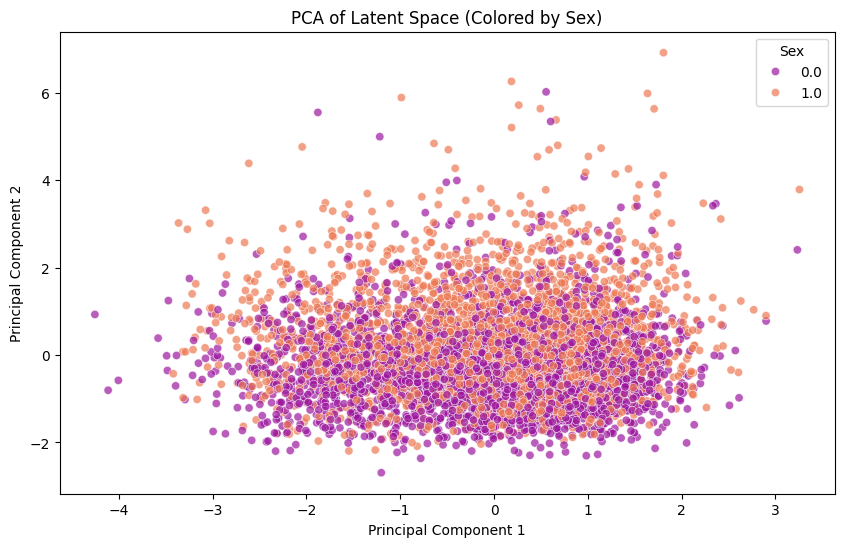

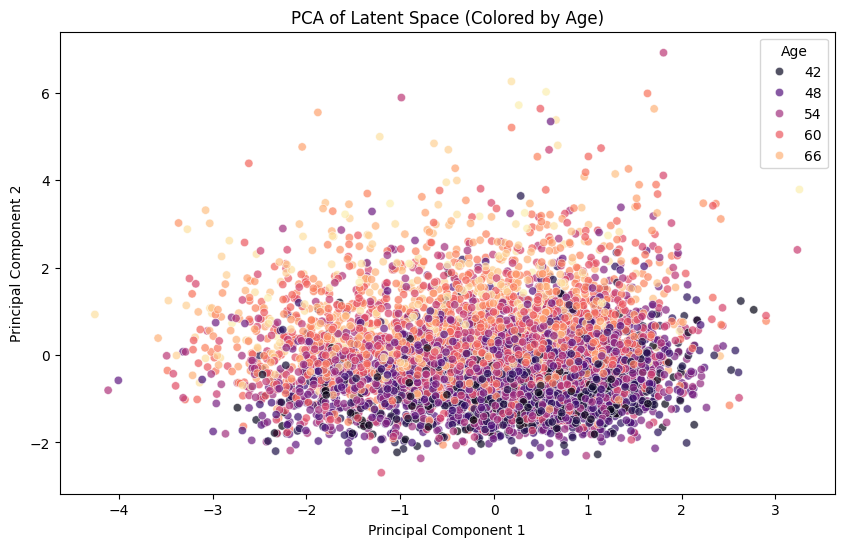

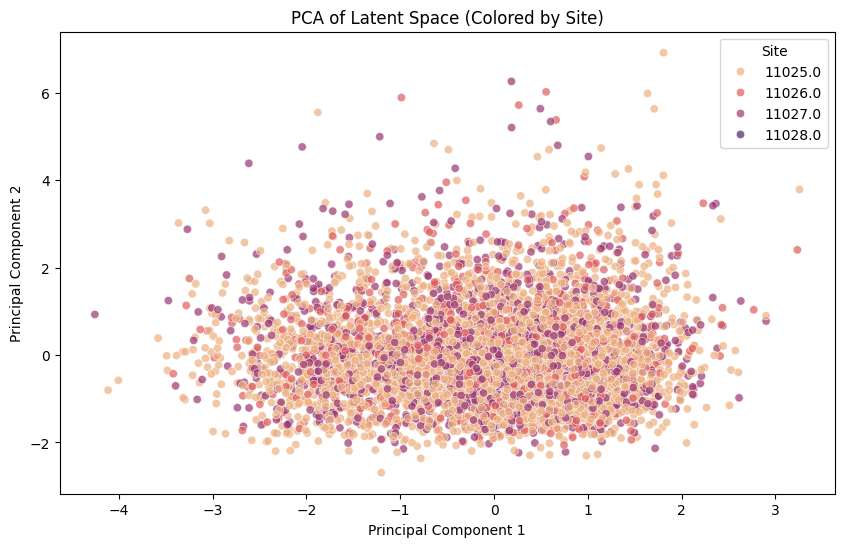

In [17]:
age = latent_pca_df_asl["Age"].values
sex = latent_pca_df_asl["Sex"].values
site = latent_pca_df_asl["Site"].values


#sex figure
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = latent_pca_df_asl,
    x="PC1",
    y="PC2",
    hue="Sex",
    palette="plasma",
    alpha=0.7
)
plt.title("PCA of Latent Space (Colored by Sex)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Sex")
plt.show()

#Age figure
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = latent_pca_df_asl,
    x="PC1",
    y="PC2",
    hue="Age",
    palette="magma",
    alpha=0.7
)
plt.title("PCA of Latent Space (Colored by Age)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Age")
plt.show()

#Site figure
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = latent_pca_df_asl,
    x="PC1",
    y="PC2",
    hue="Site",
    palette="flare",
    alpha=0.7
)
plt.title("PCA of Latent Space (Colored by Site)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Site")
plt.show()

PC1:    Cummulative variance:  18.38%,  Individual variance:  18.38%
PC2:    Cummulative variance:  35.19%,  Individual variance:  16.81%
PC3:    Cummulative variance:  49.80%,  Individual variance:  14.61%
PC4:    Cummulative variance:  61.39%,  Individual variance:  11.59%
PC5:    Cummulative variance:  70.03%,  Individual variance:  8.64%
PC6:    Cummulative variance:  77.68%,  Individual variance:  7.65%
PC7:    Cummulative variance:  84.65%,  Individual variance:  6.96%
PC8:    Cummulative variance:  90.98%,  Individual variance:  6.33%
PC9:    Cummulative variance:  96.11%,  Individual variance:  5.13%
PC10:   Cummulative variance:  100.00%,  Individual variance:  3.89%


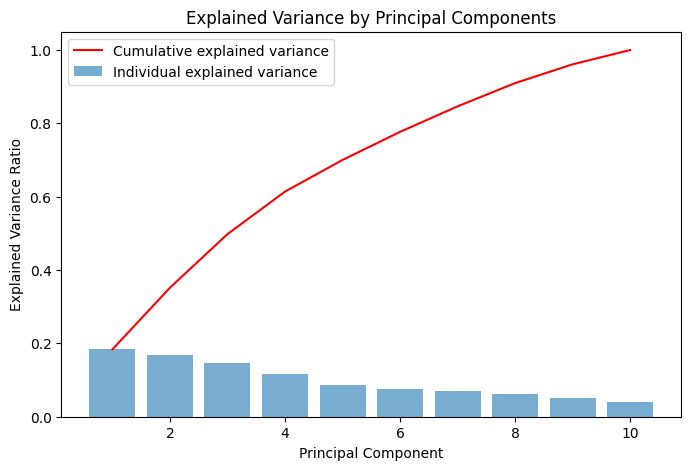

In [18]:
cummulative_variance = 0
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    cummulative_variance += var
    if i < 10: 
        print(f'PC{i}:    Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
    else:
        print(f'PC{i}:   Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')

#plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.6, label='Individual explained variance')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'r-', label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend()
plt.show()

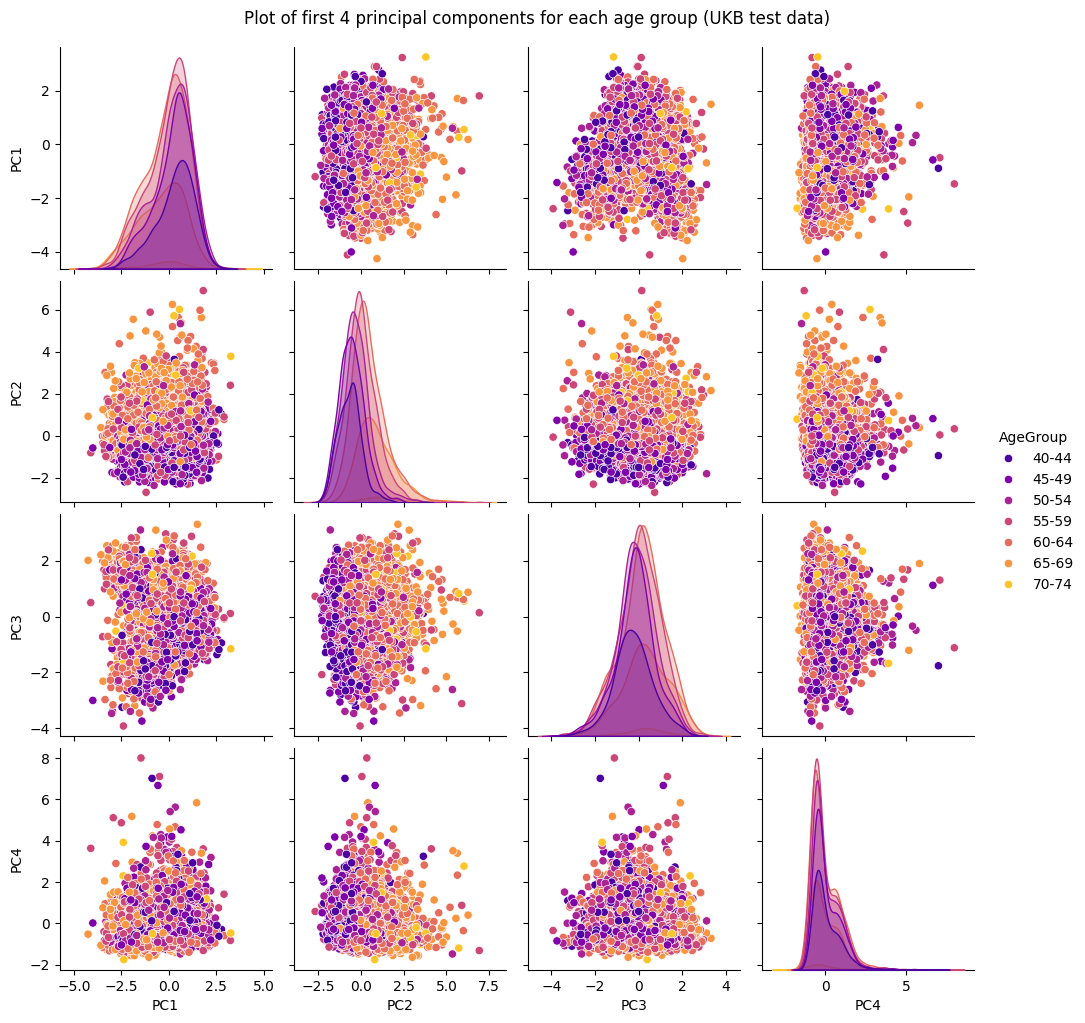

In [22]:
pca_df = pd.DataFrame(latent_pca_df_asl, columns=['PC1', 'PC2', 'PC3', 'PC4','Age','Sex','Site'])

min_age = pca_df["Age"].min()
max_age = pca_df["Age"].max()
bins = np.arange(np.floor(min_age / 5) * 5, np.ceil(max_age / 5) * 5 + 1, 5)
pca_df['AgeGroup'] = pd.cut(
    pca_df['Age'],
    bins=bins,
    labels = [f"{int(bins[i])}-{int(bins[i+1]-1)}" for i in range(len(bins)-1)],
    right=False
)

# plot for age
sns.pairplot(pca_df, hue="AgeGroup", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
plt.suptitle('Plot of first 4 principal components for each age group (UKB test data)', y=1.02)
plt.show()


# plot for sex
# sns.pairplot(pca_df, hue="Sex", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
# plt.suptitle('Plot of first 4 principal components for each sex', y=1.02)
# plt.show()

# # plot for site
# sns.pairplot(pca_df, hue="Site", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="plasma")
# plt.suptitle('Plot of first 4 principal components for each site (test data)', y=1.02)
# plt.show()
